In [1]:
!pip install gdown -q
import gdown
import pandas as pd

file_id = "16UtvtPDuaVdK_bHXoi0hhWx2X-6_8xLM"
gdown.download(id=file_id, output="train.csv", quiet=False)

df = pd.read_csv("train.csv")
df.head()

100%|██████████| 278M/278M [00:02<00:00, 103MB/s] 


,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [2]:
print("Nombre de pages :", df.shape[0])
print("Nombre de jours :", df.shape[1] - 1)

Nombre de pages : 145063
Nombre de jours : 550


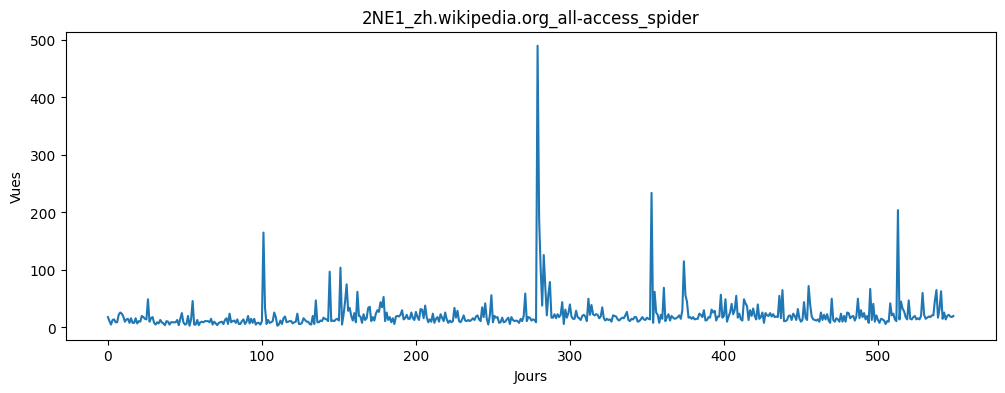

In [3]:
import matplotlib.pyplot as plt

page_name = df.iloc[0]["Page"]
serie = df.iloc[0].drop("Page")

plt.figure(figsize=(12, 4))
plt.plot(serie.values)
plt.title(page_name)
plt.xlabel("Jours")
plt.ylabel("Vues")
plt.show()

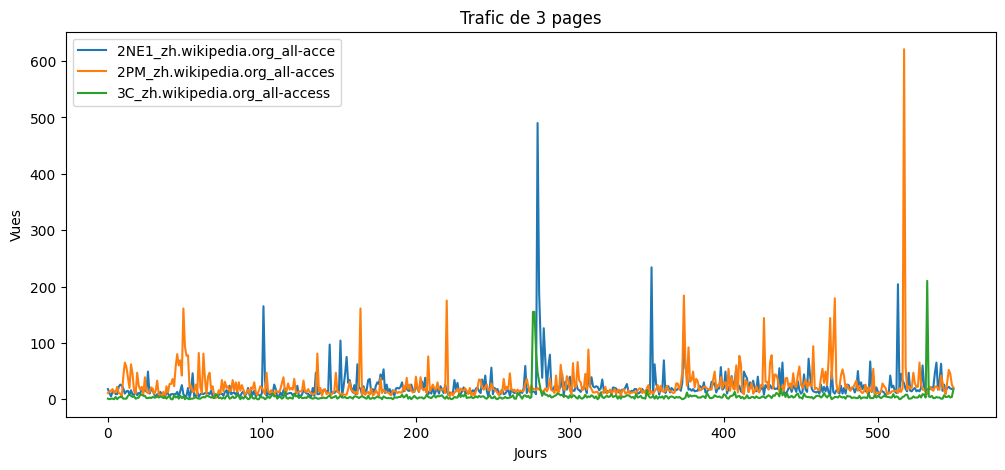

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
for i in range(3):
    nom = df.iloc[i]["Page"]
    valeurs = df.iloc[i].drop("Page").values
    plt.plot(valeurs, label=nom[:30])

plt.title("Trafic de 3 pages")
plt.xlabel("Jours")
plt.ylabel("Vues")
plt.legend()
plt.show()

In [ ]:
total_NaN = df.isna().sum().sum()
total_cases = df.shape[0] * (df.shape[1] - 1)
print("Valeurs manquantes :", total_NaN)
print("Pourcentage :", round(100 * total_NaN / total_cases, 2), "%")


Valeurs manquantes : 6192931
Pourcentage : 7.76 %


In [6]:
df = df.fillna(0)

# On vérifie qu'il ne reste plus aucun trou
print("Valeurs manquantes après nettoyage :", df.isna().sum().sum())

Valeurs manquantes après nettoyage : 0


In [7]:
# 1) Tirage au hasard
df_petit = df.sample(n=1000, random_state=42).reset_index(drop=True)
print("Pages gardées :", df_petit.shape[0])

Pages gardées : 1000


In [8]:
# 2) On vérifie que l'échantillon contient un VRAI mélange
totaux = df_petit.drop("Page", axis=1).sum(axis=1)
print("Page la moins vue :", int(totaux.min()))
print("Page la plus vue  :", int(totaux.max()))
print("Moyenne           :", int(totaux.mean()))

Page la moins vue : 0
Page la plus vue  : 16137711
Moyenne           : 436516


## Validation de la représentativité de l'échantillon (Test KS)

Statistique     Complet (145K)         Echantillon (1K)
Minimum         0                      0
25%             14629                  12721
Mediane         131825                 109222
Moyenne         720371                 436516
75%             450554                 409953
Maximum         12066181102            16137711

=== Test de Kolmogorov-Smirnov ===
Statistique KS : 0.0377
p-value        : 0.1167
✓ L'echantillon EST representatif du dataset complet


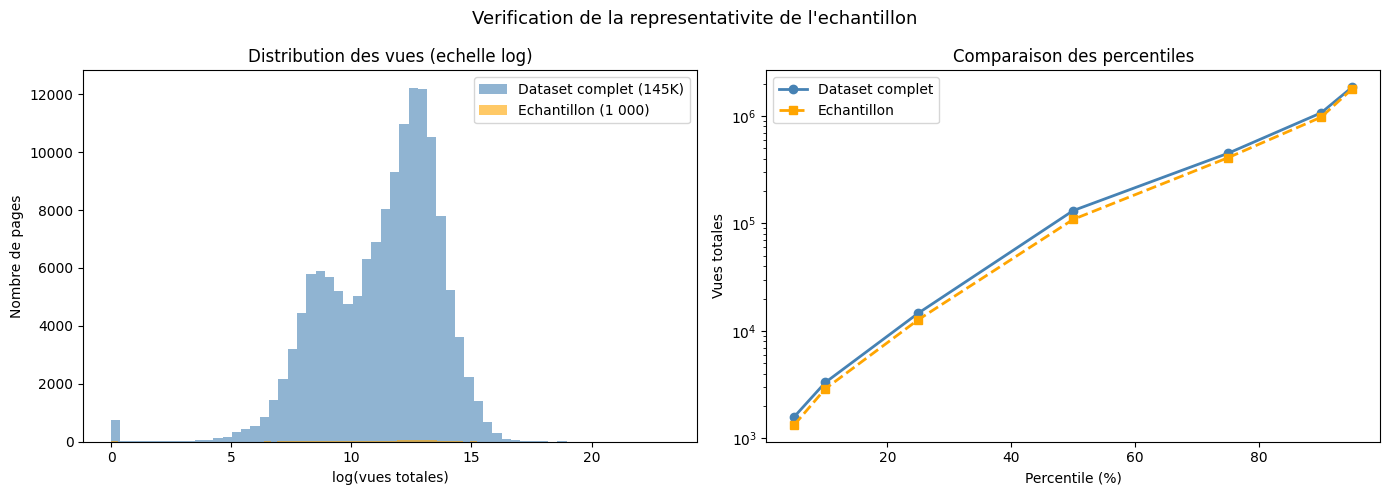

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Calcul des totaux de vues par page
totaux_complet     = df.drop("Page", axis=1).sum(axis=1)
totaux_echantillon = df_petit.drop("Page", axis=1).sum(axis=1)

# ── 1. Tableau comparatif ──────────────────────────────────────
print("=" * 55)
print(f"{'Statistique':<15} {'Complet (145K)':<22} {'Echantillon (1K)'}")
print("=" * 55)
for stat, v1, v2 in [
    ("Minimum",  totaux_complet.min(),         totaux_echantillon.min()),
    ("25%",      totaux_complet.quantile(.25),  totaux_echantillon.quantile(.25)),
    ("Mediane",  totaux_complet.median(),       totaux_echantillon.median()),
    ("Moyenne",  totaux_complet.mean(),         totaux_echantillon.mean()),
    ("75%",      totaux_complet.quantile(.75),  totaux_echantillon.quantile(.75)),
    ("Maximum",  totaux_complet.max(),          totaux_echantillon.max()),
]:
    print(f"{stat:<15} {int(v1):<22} {int(v2)}")
print("=" * 55)

# ── 2. Test de Kolmogorov-Smirnov ─────────────────────────────
ks_stat, p_value = stats.ks_2samp(
    np.log1p(totaux_complet),
    np.log1p(totaux_echantillon)
)
print(f"\n=== Test de Kolmogorov-Smirnov ===")
print(f"Statistique KS : {ks_stat:.4f}")
print(f"p-value        : {p_value:.4f}")
if p_value > 0.05:
    print("✓ L'echantillon EST representatif du dataset complet")
else:
    print("✗ L'echantillon n'est PAS representatif — on fera l'echantillonnage stratifie")

# ── 3. Graphique comparatif ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(np.log1p(totaux_complet),     bins=60,
             alpha=0.6, color='steelblue', label='Dataset complet (145K)')
axes[0].hist(np.log1p(totaux_echantillon), bins=60,
             alpha=0.6, color='orange',    label='Echantillon (1 000)')
axes[0].set_title('Distribution des vues (echelle log)')
axes[0].set_xlabel('log(vues totales)')
axes[0].set_ylabel('Nombre de pages')
axes[0].legend()

pcts   = [5, 10, 25, 50, 75, 90, 95]
p_full = [np.percentile(totaux_complet,     p) for p in pcts]
p_samp = [np.percentile(totaux_echantillon, p) for p in pcts]
axes[1].plot(pcts, p_full, 'o-',  color='steelblue', linewidth=2, label='Dataset complet')
axes[1].plot(pcts, p_samp, 's--', color='orange',    linewidth=2, label='Echantillon')
axes[1].set_title('Comparaison des percentiles')
axes[1].set_xlabel('Percentile (%)')
axes[1].set_ylabel('Vues totales')
axes[1].set_yscale('log')
axes[1].legend()

plt.suptitle("Verification de la representativite de l'echantillon", fontsize=13)
plt.tight_layout()
plt.savefig('preuve_representativite.png', dpi=120, bbox_inches='tight')
plt.show()

In [13]:
import os

# 1. Monter Drive si pas encore fait
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# 2. Créer le dossier si nécessaire (exist_ok=True = pas d'erreur s'il existe déjà)
os.makedirs("/content/drive/MyDrive/PFE_Trafic/data", exist_ok=True)

# 3. Sauvegarder df_petit
df_petit.to_csv("/content/drive/MyDrive/PFE_Trafic/data/df_petit.csv", index=False)
print("df_petit sauvegardé :", len(df_petit), "pages")

Mounted at /content/drive
df_petit sauvegardé : 1000 pages
